<u><b>Analysis of Polymarket weather markets</b></u>

#Focusing on: does the crowd favorite win?

First we need to obtain the data we want to work with for this analysis. To get the data there are three main API's that are free from polymarket, these are the GAMMA API, COLB API and DATA API. GAMMA API provides answers to questions like if a particular market exists on the site. COLB API provides info regarding the order books for markets and DATA API provides info about each user interacting with a market. 


In [ ]:
import requests
import pandas as pd
import numpy as np 
import json
import time 
from datetime import datetime, timezone, timedelta


def get_historic_events(days = 365):
    """This function pulls all event data regarding the events returning 2 data frames, the event df and the markets for a event """

    #create date range for scrapping
    end_date = datetime.now(timezone.utc)
    start_date = end_date - timedelta(days=days)

    offset = 0
    events = []

    while True:
    
        time.sleep(5)
        #filiters to get the info we want 
        params = {
            "tag_slug" : "weather", #only bring weather events
            "closed" : True, #event had ended 
            "limit" : 100, #requests a max of 100 events 
            "offset" : offset, #how far to move down
            "ascending" : False, #sort by newest to oldest
            "order" : end_date, #sort by the ending date 
            "end_date_min" : start_date.strftime("%Y-%m-%dT%H:%M:%SZ"),
            "end_date_max" : end_date.strftime("%Y-%m-%dT%H:%M:%SZ") #create event range
           
            }

        events_response = requests.get(
            "https://gamma-api.polymarket.com/events",
            params=params)

        events_response.raise_for_status()

        #converts polymarket data into a dict
        batch = events_response.json()

        #extend not append to not get ladder of lists
        events.extend(batch)

        print(f"fetched: {len(events)} events")

        if len(batch) < 100:
            break
        else:
            offset += len(batch)


    #events are repeated markets ie some bet
    
    markets_rows = []
    events_clean = []

    for e in events:
        markets = e.pop("markets", []) or []
        events_clean.append(e)

        for m in markets:
            m["event_id"] = e.get("id")
            m["event_title"] = e.get("title")
            m["event_slug"] = e.get("slug")
            markets_rows.append(m)

    df_events = pd.DataFrame(events_clean)
    df_markets = pd.DataFrame(markets_rows)

    print(f"Total markets: {len(df_markets)}")

    return df_events, df_markets


df_events, df_markets = get_historic_events(days = 19)#crashs if more than 19 days cause of how getting data from the api

df_events.to_csv("events.csv",index=False)


fetched: 100 events
fetched: 200 events
fetched: 300 events
fetched: 400 events
fetched: 500 events
fetched: 600 events
fetched: 700 events
fetched: 800 events
fetched: 900 events
fetched: 1000 events
fetched: 1100 events
fetched: 1200 events
fetched: 1300 events
fetched: 1400 events
fetched: 1500 events
fetched: 1600 events
fetched: 1700 events
fetched: 1800 events
fetched: 1900 events
fetched: 2000 events
fetched: 2017 events
Total markets: 22333


In [8]:

#convert dates in 2026-09-05T12:00:00Z to unix format
def to_unix_timestamp(date_text):
    date = datetime.fromisoformat(
        date_text.replace("Z", "+00:00")
    )
    return int(date.timestamp())

We can now collect data about the weather events and the markets price history. However we now need to proccess and clean the data to only have "temperature prediction" markets that we want to investigate. 

In [9]:

import re


def event_classifier(title_column):
    """create set of defined rules that classify each event """

    #various regex rules to identify the type of event 
    EVENT_TYPE_RULES = [
    ('Temperature', r'\b(?:temperatures?|hottest|coldest|heat\s*waves?|degrees?\s*[cf])\b'),
    ('Earthquake', r'\b(?:earthquakes?|seismic|tsunamis?)\b'),
    ('Hurricane / Typhoon', r'\b(?:hurricanes?|typhoons?|cyclones?|tropical\s+(?:storms?|depressions?))\b'),
    ('Solar / Space Wx', r'\b(?:solar|geomagnetic|auroras?|space\s+weather|coronal)\b'),
    ('Flu / Respiratory', r'\b(?:flu|influenza|respiratory|rsv|covid(?:\s*19)?|h5n1|bird\s+flu)\b'),
    ('Infectious Disease', r'\b(?:measles|mpox|monkeypox|ebola|dengue|malaria|polio|outbreaks?|pandemics?|infectious\s+disease)\b'),
    ('Snow / Ice', r'\b(?:snow\w*|blizzards?|ice|icy|freez\w*|frost|hail\w*)\b'),
    ('Tornado', r'\b(?:tornado(?:es|s)?|twisters?)\b'),
    ('Rain / Flood', r'\b(?:rain\w*|flood\w*|precipitation|monsoons?)\b'),
    ('General Storm', r'\b(?:storms?|thunderstorms?|wind\w*)\b'),
    ('Drought', r'\b(?:droughts?)\b'),
    ('Wildfire', r'\b(?:wildfires?|forest\s+fires?|bushfires?)\b'),
    ('Volcano', r'\b(?:volcan\w*|eruptions?)\b'),
]

    classification = []

    for title in title_column:
        classified = "other"

        for pattern in EVENT_TYPE_RULES:
            if re.search(pattern[1], title, flags=re.IGNORECASE):
                classified = pattern[0]
                break          

        classification.append(classified)
    return classification

df_events["event_type"] = event_classifier(df_events["title"])



Overall from the plot below we can see the composition of the weather market space, where we can see "temperature" markets make up the overwhelming majority of the weather event space. Meaning we can filter down to only the temperature market without losing much extra info.   

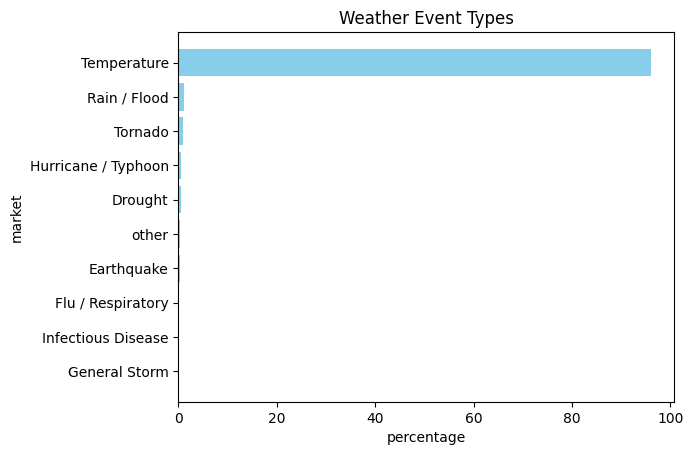

In [10]:
import matplotlib.pyplot as plt

percentages = (
    df_events["event_type"]
    .value_counts(normalize=True)
    .sort_values()
    .mul(100))


plt.barh(percentages.index, percentages.values, color='skyblue')

plt.title("Weather Event Types")
plt.xlabel("percentage")
plt.ylabel("market")

plt.show()

In [11]:
#keep only temperature data
df_events = df_events[df_events["event_type"] == "Temperature"]

#keep the markets that are temperature related only 
df_markets = df_markets[df_markets["event_id"].isin(df_events["id"])]


#removes rows that do not have a normal on chain condition linking their outcomes to settlement
df_markets = df_markets.dropna(subset=["conditionId"])

#create col for "yes" bet and "no" bet extracted from the clobtokenID 
tokens = df_markets["clobTokenIds"].apply(json.loads)
df_markets["clobToken_yes"] = tokens.str[0]
df_markets["clobToken_no"] = tokens.str[1]

#finding the bucket that won
def resolved_yes(row):
    if not row["closed"] or pd.isna(row["outcomePrices"]):
        return None
    elif float(json.loads(row["outcomePrices"])[0]) == 1:
        return 1
    else:
        return 0 

df_markets["yes_won"] = df_markets.apply(resolved_yes, axis=1)

#ensure each event has only one winner else dropped this is done as it is a known glitch 
event_check = (
    df_markets.groupby("event_id")
    .agg(
        market_count=("id", "nunique"),
        winning_bucket_count=("yes_won", lambda x: x.eq(1).sum())
    )
)

event_check["exactly_one_winner"] = (
    event_check["winning_bucket_count"] == 1
)

valid_event_ids = event_check[
    event_check["exactly_one_winner"]
].index

df_markets = df_markets[df_markets["event_id"].isin(valid_event_ids)]



<b>Time to work on the price history</b>

time to learn some new things like async functions and when to use them!
->using asnyc functions will allow the code move on while running a function in the background that takes a long time
->Useful for us as we scrapping all the markets price history every 30min (takes a long time!)  

In [ ]:
import asyncio
import aiohttp

def time_chuncks(start_ts, end_ts, chunck_day=7):
    """split a Unix timestamp range into smaller chunks."""

    start_date = to_unix_timestamp(start_ts)
    end_date = to_unix_timestamp(end_ts)
    chunck_size_unix = chunck_day * 24 * 60 * 60
    current_start = start_date

    while current_start < end_date:
        current_end = min(current_start + chunck_size_unix, end_date)
        #yield creates a generator function which drips info to whatever calls it to prevent a crash
        yield current_start, current_end

        current_start = current_end


async def fetch_chunk(current_start, current_end, clobtoken_id, fidelity, sem):
    """proccess a chunk by getting the price data for the given chunk"""

    params = {
        "market" : clobtoken_id,
        "startTs" : current_start,
        "endTs": current_end,
        "interval": "all",
        "fidelity": fidelity,
    } 
    async with sem:
        async with aiohttp.ClientSession() as session:
            async with session.get(
                "https://clob.polymarket.com/prices-history",
                params=params
            ) as response:

                response.raise_for_status()
                data = await response.json()


    return data.get("history", [])

#all this async stuff is objects that interact with each other thus no variables??


async def get_price_history(start_ts, end_ts, clobtoken_id, fidelity=60):
    """main function that calles fetch_chunk for all the markets"""

    #creates 100 requests max
    sem = asyncio.Semaphore(100)
    tasks = []

    #go through each block getting the price history 
    for current_start, current_end in time_chuncks(start_ts, end_ts):
        task = fetch_chunk(current_start, current_end, clobtoken_id, fidelity, sem)
        tasks.append(task)

    #unpacks the list and calls the fetch_chuck concurrently and collects the info
    chunk_results = await asyncio.gather(*tasks) 

    complete_chunks = []

    for chunk in chunk_results:
        complete_chunks.extend(chunk)

    complete_chunks.sort(key=lambda price_point: int(price_point["t"]))

    return complete_chunks


final_price_history = []

for index, row in df_markets.iterrows():
    market_history = await get_price_history(
        row["startDate"],
        row["endDate"],
        row["clobToken_yes"]
    )

    for price_point in market_history:
        price_point["market_id"] = row["id"]
        price_point["question"] = row["question"]
        price_point["clobtoken_id"] = row["clobToken_yes"]
        price_point["bucket"] = row["groupItemTitle"]
        price_point["event_id"] = row["event_id"]
    final_price_history.extend(market_history)




price_history_df = pd.DataFrame(final_price_history)
price_history_df.to_csv("price_history.csv",index=False)

price_history_df

In [ ]:
price_data = pd.read_csv("price_history.csv")
market_price_data = price_data[price_data["event_id"] == 986599]

market_price_data.groupby("market_id").count()

